# Import Required Libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import random
import os

# Load Text File

In [ ]:
file_path = "/content/data.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text = file.read().lower()

print("Sample Text:\n")
print(text[:500])

Sample Text:

the king ruled the ancient kingdom with wisdom and courage.
the people of the kingdom respected the king deeply.
every morning the king walked through the royal gardens.
the royal gardens were filled with roses and jasmine.
the fragrance of flowers filled the cool morning air.
the queen often joined the king in the gardens.
the queen believed in kindness and compassion.
the kingdom was surrounded by tall mountains.
beyond the mountains lay a dense forest.
the forest was mysterious and full of se


# Create Vocabulary and Tokenize

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Total Vocabulary Size:", total_words)

Total Vocabulary Size: 394


In this step, the text is converted into numbers.

Computers cannot understand words directly, so we create a vocabulary where:

* Each unique word is assigned a unique integer value.

For example:
king → 5
queen → 12

This step converts human language into machine-understandable format.

# Create Input Sequences

In [ ]:
input_sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Total Training Sequences:", len(input_sequences))

Total Training Sequences: 672


Now we create training sequences using N-gram patterns.

For example:
"The king ruled wisely"

Becomes:

* The → king

* The king → ruled

* The king ruled → wisely

This helps the model learn:
Given previous words, what is the next word?

This step builds context-based learning data.

# Pad Sequences

In [ ]:
max_seq_len = max([len(seq) for seq in input_sequences])

input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')

print("Maximum Sequence Length:", max_seq_len)

Maximum Sequence Length: 10


All input sequences may not be the same length.
Neural networks require fixed-size inputs.

So we pad shorter sequences with zeros at the beginning.

Example:
[king ruled] → [0 0 king ruled]

This step ensures uniform input size for training.

# Split into X and y

In [ ]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (672, 9)
y shape: (672, 394)


Here we split the data into:

* X → Input words

* y → Target word (next word)

The output word is converted into categorical format (one-hot encoding).

This means the model predicts probability distribution across the entire vocabulary.

This step prepares the data for supervised learning.

# Build Simple RNN Model

In [ ]:
def build_rnn_model():
    model = Sequential([
        Embedding(total_words, 100, input_length=max_seq_len-1),
        SimpleRNN(150),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

rnn_model = build_rnn_model()
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

We create a neural network using:

* Embedding Layer → Converts word numbers into dense vectors

* SimpleRNN Layer → Learns sequential patterns

* Dropout → Prevents overfitting

* Dense Layer → Predicts next word using softmax

Simple RNN remembers short-term patterns but struggles with long sentences.

This model captures short-term dependencies in text.

# Build LSTM Model

In [ ]:
def build_lstm_model():
    model = Sequential([
        Embedding(total_words, 100, input_length=max_seq_len-1),
        LSTM(150),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Here we replace the SimpleRNN layer with LSTM.

LSTM contains memory cells and gates:

* Forget gate

* Input gate

* Output gate

These gates help preserve long-term dependencies and avoid vanishing gradient problems.

LSTM understands long context better than RNN.

# Train Models

In [ ]:
early_stop = EarlyStopping(monitor='loss', patience=3)

print("Training RNN Model...")
history_rnn = rnn_model.fit(X, y,
                            epochs=90,
                            batch_size=64,
                            verbose=1,
                            callbacks=[early_stop])

print("Training LSTM Model...")
history_lstm = lstm_model.fit(X, y,
                              epochs=90,
                              batch_size=64,
                              verbose=1,
                              callbacks=[early_stop])

Training RNN Model...
Epoch 1/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5772 - loss: 2.1518
Epoch 2/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6034 - loss: 2.0453
Epoch 3/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5988 - loss: 1.9629
Epoch 4/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6612 - loss: 1.8555
Epoch 5/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6660 - loss: 1.7490
Epoch 6/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6953 - loss: 1.6841
Epoch 7/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7016 - loss: 1.5907
Epoch 8/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7390 - loss: 1.4607
Epoch 9/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7426 - loss: 1.4141
Epoch 10/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7293 - loss: 1.3702
Epoch 11/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7536 - loss: 1.3657
Epoch 12/90
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s

The models are trained for multiple epochs.

During training:

* The model compares predictions with actual words.

* It calculates loss.

* It updates weights using backpropagation.

* Accuracy gradually improves.

Early stopping prevents overfitting.

This step teaches the model language patterns.

# Plot Training Accuracy (Extra for Self Learning)

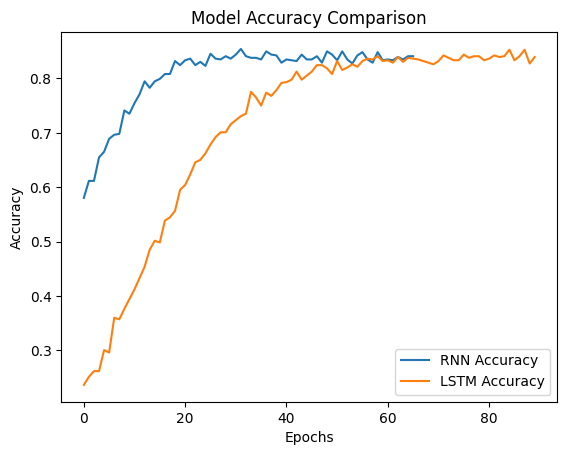

In [ ]:
plt.plot(history_rnn.history['accuracy'], label='RNN Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Accuracy')
plt.legend()
plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

We plot training accuracy of RNN and LSTM.

This helps us visually compare:

* Which model learns better?

* Which model converges faster?

Usually, LSTM performs better.

This step provides performance comparison.

# Perplexity Calculation (Advanced Component)

In [ ]:
rnn_loss = history_rnn.history['loss'][-1]
lstm_loss = history_lstm.history['loss'][-1]

print("RNN Perplexity:", np.exp(rnn_loss))
print("LSTM Perplexity:", np.exp(lstm_loss))

RNN Perplexity: 1.6329260885935513
LSTM Perplexity: 1.7721787394200765


Perplexity measures how well the model predicts text.

Formula:
Perplexity = exp(loss)

Lower perplexity → Better language understanding.

This is an advanced evaluation metric used in NLP.

# Text Generation Function (Temperature-Based)

In [ ]:
def generate_text(model, seed_text, next_words=20, temperature=1.0):

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        predictions = model.predict(token_list, verbose=0)[0]

        predictions = np.log(predictions + 1e-8) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)

        predicted_index = np.random.choice(len(predictions), p=predictions)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

This function generates new text using a seed sentence.

Steps:

1. Convert seed text into tokens

2. Predict next word probability

3. Select next word

4. Append to sentence

5. Repeat

Temperature parameter controls creativity:

* Low → Safe predictions

* High → More random

This step makes the model creative.

# Generate New Text

In [ ]:
seed = "the king"

print("\n--- RNN Generated Text ---")
print(generate_text(rnn_model, seed, 25, temperature=1.0))

print("\n--- LSTM Generated Text ---")
print(generate_text(lstm_model, seed, 25, temperature=1.0))


--- RNN Generated Text ---
the king aged gracefully ancient spread every morning the future waited patiently poets composed beautiful addressed time echoed seeking calm humble books lasted knights trained yet farmers

--- LSTM Generated Text ---
the king listened carefully to every story gardens seeking of the royal morning the king walked land with years warrior warrior melodies peacefully requested prosperity trade swords


Here we test the trained model using a starting phrase like:

"The king"

The model generates 20–30 new words.

If training is good:

* Sentences will resemble original style.

* Grammar may not be perfect but structure looks meaningful.

This step validates the model practically.

# Save Models (Extra Component)

In [ ]:
rnn_model.save("rnn_nextword_model.h5")
lstm_model.save("lstm_nextword_model.h5")

print("Models saved successfully!")

Models saved successfully!


Finally, we save trained models as .h5 files.

This allows:

* Reusing the model later

* Deploying in applications

* Avoiding retraining

This step completes the implementation lifecycle.